# Imports

In [1]:
import os
import pickle
import time
from collections import Counter
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from backend.osu_oracle_pytorch.oracle.utils_training import (get_data, get_additional_features, pad_sequences_pt,
                                                              train_and_evaluate, plot_training_history, load_pytorch_models)
from backend.osu_oracle_pytorch.oracle.cnn_model import CNN_Model
from backend.osu_oracle_pytorch.oracle.pruning import prune_models

# Model Testing

Go run test_model.py

# Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

db_path = 'beatmaps.db'
X, y, beatmap_ids = get_data(db_path, augment=True)

additional_features = get_additional_features(db_path)

additional_features_array = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids
])

In [14]:
X_train, X_test, y_train, y_test, beatmap_ids_train, beatmap_ids_test = train_test_split(
    X,
    y,
    beatmap_ids,
    test_size=0.2,
    random_state=42
)

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

with open('./models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

y_train_numerical = label_encoder.transform(y_train)
y_test_numerical = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

y_train_numerical = torch.tensor(y_train_numerical, dtype=torch.long)
y_test_numerical = torch.tensor(y_test_numerical, dtype=torch.long)

# Pad sequences
max_length = max(len(seq) for seq in X)
X_train = pad_sequences_pt(
    X_train,
    maxlen=max_length,
    dtype=torch.float32
)
X_test = pad_sequences_pt(
    X_test,
    maxlen=max_length,
    dtype=torch.float32
)

print(X_train.shape)
print(X_test.shape)

torch.Size([41027, 3406, 4])
torch.Size([10257, 3406, 4])


In [15]:
# (batch, sequence_length, features)
# but Conv1d expects (batch, channels, sequence_length)
X_train = X_train.permute(0, 2, 1)
X_test = X_test.permute(0, 2, 1)

print(X_train.shape)
print(X_test.shape)

torch.Size([41027, 4, 3406])
torch.Size([10257, 4, 3406])


In [16]:
class_counts = Counter(y_train_numerical.numpy())

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

Class 0: 8362
Class 1: 6884
Class 2: 7989
Class 3: 6986
Class 4: 3802
Class 5: 7004


# CNN Model Training

X_train: torch.Size([41027, 4, 3406])
X_test: torch.Size([10257, 4, 3406])
y_train: torch.Size([41027])
y_test: torch.Size([10257])
Epoch 1/50 - loss: 1.5482 - acc: 0.3616 - val_loss: 1.3877 - val_acc: 0.4488
Epoch 2/50 - loss: 1.3338 - acc: 0.4820 - val_loss: 1.2383 - val_acc: 0.5187
Epoch 3/50 - loss: 1.2576 - acc: 0.5200 - val_loss: 1.1948 - val_acc: 0.5339
Epoch 4/50 - loss: 1.2038 - acc: 0.5432 - val_loss: 1.1664 - val_acc: 0.5507
Epoch 5/50 - loss: 1.1650 - acc: 0.5610 - val_loss: 1.1209 - val_acc: 0.5700
Epoch 6/50 - loss: 1.1286 - acc: 0.5722 - val_loss: 1.1243 - val_acc: 0.5594
Epoch 7/50 - loss: 1.0996 - acc: 0.5878 - val_loss: 1.0666 - val_acc: 0.5919
Epoch 8/50 - loss: 1.0714 - acc: 0.5944 - val_loss: 1.0570 - val_acc: 0.5884
Epoch 9/50 - loss: 1.0346 - acc: 0.6095 - val_loss: 1.0192 - val_acc: 0.6060
Epoch 10/50 - loss: 1.0035 - acc: 0.6228 - val_loss: 0.9922 - val_acc: 0.6285
Epoch 11/50 - loss: 0.9770 - acc: 0.6329 - val_loss: 0.9668 - val_acc: 0.6364
Epoch 12/50 - loss:

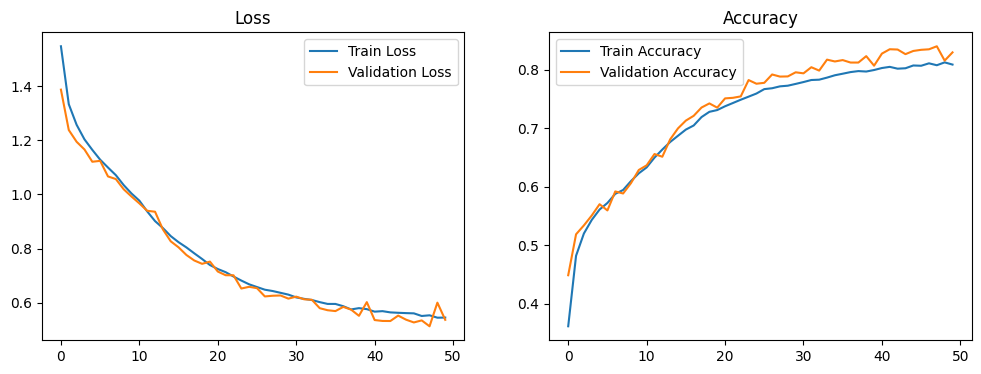

X_train: torch.Size([41027, 4, 3406])
X_test: torch.Size([10257, 4, 3406])
y_train: torch.Size([41027])
y_test: torch.Size([10257])
Epoch 1/50 - loss: 1.5960 - acc: 0.3233 - val_loss: 1.4867 - val_acc: 0.3720
Epoch 2/50 - loss: 1.3924 - acc: 0.4454 - val_loss: 1.2723 - val_acc: 0.4997
Epoch 3/50 - loss: 1.2939 - acc: 0.5007 - val_loss: 1.2151 - val_acc: 0.5259
Epoch 4/50 - loss: 1.2509 - acc: 0.5250 - val_loss: 1.1962 - val_acc: 0.5383
Epoch 5/50 - loss: 1.2137 - acc: 0.5385 - val_loss: 1.1718 - val_acc: 0.5534
Epoch 6/50 - loss: 1.1833 - acc: 0.5505 - val_loss: 1.1644 - val_acc: 0.5460
Epoch 7/50 - loss: 1.1477 - acc: 0.5670 - val_loss: 1.1158 - val_acc: 0.5653
Epoch 8/50 - loss: 1.1215 - acc: 0.5754 - val_loss: 1.0688 - val_acc: 0.5887
Epoch 9/50 - loss: 1.0886 - acc: 0.5879 - val_loss: 1.0650 - val_acc: 0.5925
Epoch 10/50 - loss: 1.0572 - acc: 0.6009 - val_loss: 1.0166 - val_acc: 0.6179
Epoch 11/50 - loss: 1.0293 - acc: 0.6153 - val_loss: 0.9863 - val_acc: 0.6264
Epoch 12/50 - loss:

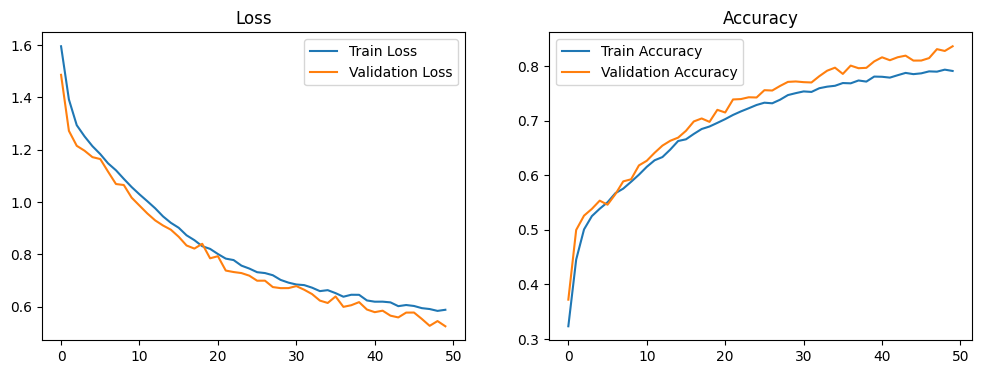

X_train: torch.Size([41027, 4, 3406])
X_test: torch.Size([10257, 4, 3406])
y_train: torch.Size([41027])
y_test: torch.Size([10257])
Epoch 1/50 - loss: 1.5998 - acc: 0.3302 - val_loss: 1.4514 - val_acc: 0.4058
Epoch 2/50 - loss: 1.4146 - acc: 0.4373 - val_loss: 1.2939 - val_acc: 0.4943
Epoch 3/50 - loss: 1.3086 - acc: 0.4935 - val_loss: 1.2524 - val_acc: 0.5200
Epoch 4/50 - loss: 1.2518 - acc: 0.5188 - val_loss: 1.2370 - val_acc: 0.5214
Epoch 5/50 - loss: 1.2078 - acc: 0.5427 - val_loss: 1.1369 - val_acc: 0.5594
Epoch 6/50 - loss: 1.1602 - acc: 0.5599 - val_loss: 1.1191 - val_acc: 0.5656
Epoch 7/50 - loss: 1.1233 - acc: 0.5764 - val_loss: 1.0784 - val_acc: 0.5837
Epoch 8/50 - loss: 1.0863 - acc: 0.5914 - val_loss: 1.1101 - val_acc: 0.5703
Epoch 9/50 - loss: 1.0530 - acc: 0.6013 - val_loss: 1.0199 - val_acc: 0.6105
Epoch 10/50 - loss: 1.0222 - acc: 0.6152 - val_loss: 0.9736 - val_acc: 0.6258
Epoch 11/50 - loss: 0.9804 - acc: 0.6311 - val_loss: 0.9477 - val_acc: 0.6419
Epoch 12/50 - loss:

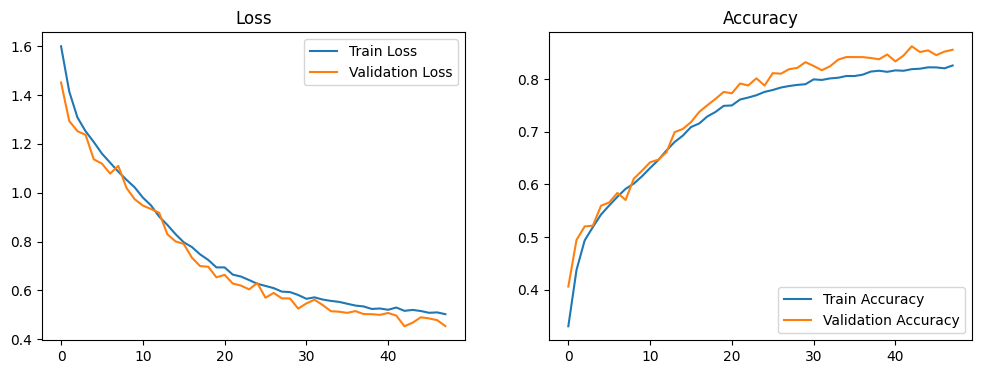

X_train: torch.Size([41027, 4, 3406])
X_test: torch.Size([10257, 4, 3406])
y_train: torch.Size([41027])
y_test: torch.Size([10257])
Epoch 1/50 - loss: 1.5897 - acc: 0.3341 - val_loss: 1.4196 - val_acc: 0.4105
Epoch 2/50 - loss: 1.3703 - acc: 0.4596 - val_loss: 1.2693 - val_acc: 0.5059
Epoch 3/50 - loss: 1.2821 - acc: 0.4998 - val_loss: 1.2315 - val_acc: 0.5162
Epoch 4/50 - loss: 1.2238 - acc: 0.5288 - val_loss: 1.1510 - val_acc: 0.5536
Epoch 5/50 - loss: 1.1815 - acc: 0.5461 - val_loss: 1.1219 - val_acc: 0.5636
Epoch 6/50 - loss: 1.1388 - acc: 0.5664 - val_loss: 1.0805 - val_acc: 0.5929
Epoch 7/50 - loss: 1.0945 - acc: 0.5824 - val_loss: 1.0508 - val_acc: 0.5961
Epoch 8/50 - loss: 1.0658 - acc: 0.5969 - val_loss: 1.0231 - val_acc: 0.6138
Epoch 9/50 - loss: 1.0226 - acc: 0.6200 - val_loss: 0.9656 - val_acc: 0.6473
Epoch 10/50 - loss: 0.9789 - acc: 0.6375 - val_loss: 0.9109 - val_acc: 0.6583
Epoch 11/50 - loss: 0.9417 - acc: 0.6521 - val_loss: 0.9155 - val_acc: 0.6638
Epoch 12/50 - loss:

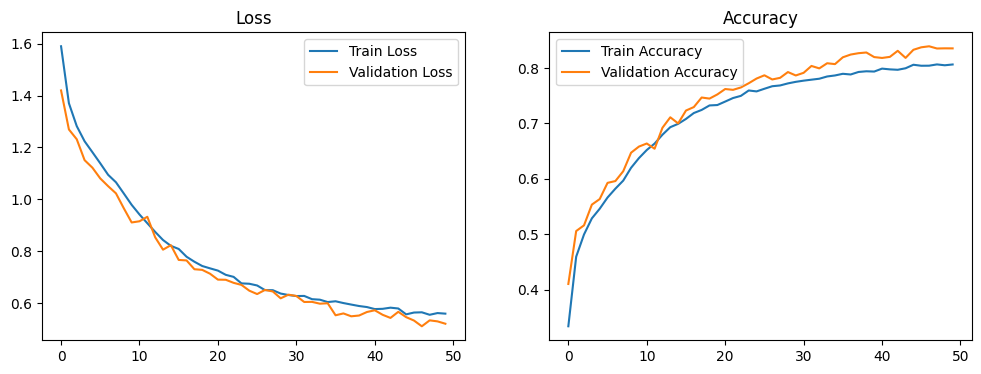

X_train: torch.Size([41027, 4, 3406])
X_test: torch.Size([10257, 4, 3406])
y_train: torch.Size([41027])
y_test: torch.Size([10257])
Epoch 1/50 - loss: 1.5861 - acc: 0.3304 - val_loss: 1.4149 - val_acc: 0.4171
Epoch 2/50 - loss: 1.3694 - acc: 0.4582 - val_loss: 1.2693 - val_acc: 0.5100
Epoch 3/50 - loss: 1.3019 - acc: 0.4904 - val_loss: 1.2477 - val_acc: 0.5105
Epoch 4/50 - loss: 1.2633 - acc: 0.5157 - val_loss: 1.2215 - val_acc: 0.5298
Epoch 5/50 - loss: 1.2094 - acc: 0.5422 - val_loss: 1.1716 - val_acc: 0.5495
Epoch 6/50 - loss: 1.1812 - acc: 0.5500 - val_loss: 1.1279 - val_acc: 0.5632
Epoch 7/50 - loss: 1.1468 - acc: 0.5661 - val_loss: 1.1017 - val_acc: 0.5805
Epoch 8/50 - loss: 1.1180 - acc: 0.5804 - val_loss: 1.0907 - val_acc: 0.5809
Epoch 9/50 - loss: 1.0995 - acc: 0.5834 - val_loss: 1.0431 - val_acc: 0.6025
Epoch 10/50 - loss: 1.0720 - acc: 0.5948 - val_loss: 1.0230 - val_acc: 0.6107
Epoch 11/50 - loss: 1.0445 - acc: 0.6070 - val_loss: 1.0057 - val_acc: 0.6267
Epoch 12/50 - loss:

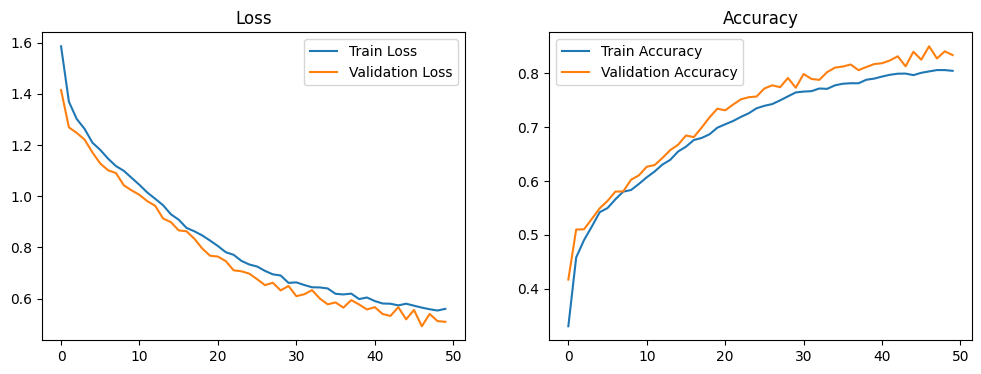

In [17]:
input_channels = X_train.shape[1]

n_estimators = 5
bagging_models = []

for i in range(n_estimators):

    X_bagging_train, _, y_bagging_train, _ = train_test_split(
        X_train,
        y_train_numerical,
        test_size=0.35,
        stratify=y_train_numerical,
        random_state=42 + i
    )

    model, history = train_and_evaluate(
        X_bagging_train,
        y_bagging_train,
        X_test,
        y_test_numerical,
        input_channels,
        num_classes,
        max_length,
        learning_rate=0.001,
        dropout_rate=0.5,
        l2_reg=0.001,
        batch_size=16,
        epochs=50,
        patience=5
    )

    plot_training_history(history)
    bagging_models.append(model)

# save
os.makedirs('./models/bagged_cnn_models', exist_ok=True)

for i, model in enumerate(bagging_models):
    torch.save(model.state_dict(), f'./models/bagged_cnn_models/bagged_cnn_model_{i}.pth')

In [18]:
# Use the average prediction of the bagging models
y_preds = []

for model in bagging_models:
    model.eval()
    model.to(device)

    with torch.no_grad():
        inputs = X_test.to(device)

        outputs = model(inputs)
        y_pred = torch.softmax(outputs, dim=1)

    y_preds.append(y_pred.cpu().numpy())

y_preds_mean = np.mean(y_preds, axis=0)
y_preds_mean_numerical = np.argmax(y_preds_mean, axis=1)

score = accuracy_score(y_test_numerical, y_preds_mean_numerical)
cm = confusion_matrix(y_test_numerical, y_preds_mean_numerical)
report = classification_report(
    y_test_numerical,
    y_preds_mean_numerical,
    zero_division=0
)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score}")

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      2122
           1       0.89      0.94      0.91      1684
           2       0.93      0.93      0.93      1963
           3       0.93      0.95      0.94      1806
           4       0.97      0.81      0.89       926
           5       0.91      0.91      0.91      1756

    accuracy                           0.92     10257
   macro avg       0.93      0.91      0.92     10257
weighted avg       0.93      0.92      0.92     10257

Confusion Matrix:
 [[2016   27   48   12    2   17]
 [  20 1580   20   18   19   27]
 [  38   22 1820   34    0   49]
 [   1   34   16 1707    0   48]
 [  22   86   17   25  752   24]
 [  28   34   44   47    0 1603]]
Accuracy: 0.9240518670176465


In [19]:
unique_true = np.unique(y_test_numerical)
unique_pred = np.unique(y_preds_mean_numerical)

print("Classes in test set:     ", unique_true)
print("Classes predicted:      ", unique_pred)

missing_predictions = np.setdiff1d(unique_true, unique_pred)

print("Classes never predicted:", missing_predictions)

Classes in test set:      [0 1 2 3 4 5]
Classes predicted:       [0 1 2 3 4 5]
Classes never predicted: []


# Meta Model

In [ ]:
def get_bagged_model_predictions(models, X, batch_size=16):
    dataset = torch.utils.data.TensorDataset(torch.as_tensor(X, dtype=torch.float32))
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_model_predictions = []

    for model in models:
        model.to(device)
        model.eval()

        model_predictions = []

        with torch.no_grad():
            for (inputs,) in dataloader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                probabilities = torch.softmax(outputs, dim=1)
                model_predictions.append(probabilities.cpu())

        model_predictions = torch.cat(model_predictions, dim=0)
        all_model_predictions.append(model_predictions)

        # move model back to CPU before loading the next model onto the GPU.
        model.cpu()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # [num_models, num_samples, num_classes]
    all_model_predictions = torch.stack(all_model_predictions)

    # Average predictions across models
    # [num_samples, num_classes]
    y_preds_mean = all_model_predictions.mean(dim=0)

    return y_preds_mean

In [ ]:
X_additional_train = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids_train
])

X_additional_test = np.array([
    additional_features[beatmap_id]
    for beatmap_id in beatmap_ids_test
])

bagged_model_train_predictions = get_bagged_model_predictions(bagging_models, X_train)
bagged_model_test_predictions = get_bagged_model_predictions(bagging_models, X_test)

X_meta_train = np.hstack((X_additional_train, bagged_model_train_predictions))
X_meta_test = np.hstack((X_additional_test, bagged_model_test_predictions))

In [22]:
from sklearn.ensemble import RandomForestClassifier

meta_model = RandomForestClassifier(n_estimators=100, random_state=42)
meta_model.fit(X_meta_train, y_train_numerical)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
y_meta_pred_numerical = meta_model.predict(X_meta_test)
meta_score = accuracy_score(y_test_numerical, y_meta_pred_numerical)
meta_cm = confusion_matrix(y_test_numerical, y_meta_pred_numerical)
meta_report = classification_report(
    y_test_numerical,
    y_meta_pred_numerical,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
)

print("Meta-model Classification Report:\n", meta_report)
print("Meta-model Confusion Matrix:\n", meta_cm)
print(f"Meta-model Accuracy: {meta_score}")

Meta-model Classification Report:
               precision    recall  f1-score   support

         NM1       0.99      0.98      0.98      2122
         NM2       0.97      0.96      0.97      1684
         NM3       0.97      0.97      0.97      1963
         NM4       0.97      0.98      0.98      1806
         NM5       0.96      0.95      0.96       926
         NM6       0.95      0.96      0.96      1756

    accuracy                           0.97     10257
   macro avg       0.97      0.97      0.97     10257
weighted avg       0.97      0.97      0.97     10257

Meta-model Confusion Matrix:
 [[2085    1   18    7    0   11]
 [   3 1625    1    9   32   14]
 [   8    3 1909    9    0   34]
 [   1    8    6 1763    1   27]
 [   4   29    6    3  884    0]
 [  12    5   31   18    0 1690]]
Meta-model Accuracy: 0.9706541873842254


In [24]:
print("Classes in full dataset:", len(label_encoder.classes_))
print("Classes in test set:", len(np.unique(y_test_numerical)))
print("Classes predicted:", len(np.unique(y_meta_pred_numerical)))

Classes in full dataset: 6
Classes in test set: 6
Classes predicted: 6


# Bagging vs Pruning the CNN models


### Training

In [25]:
pruned_models = prune_models(bagging_models, X_train, y_train_numerical)

os.makedirs('./models/pruned_models', exist_ok=True)

for i, model in enumerate(bagging_models):
    torch.save(model.state_dict(), f'./models/pruned_models/pruned_model_{i}.pth')


Pruning model 1/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.5514
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.6033

Pruning model 2/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.5781
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.6309

Pruning model 3/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.4996
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.5359

Pruning model 4/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.5524
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.5872

Pruning model 5/5
  Epoch 1/2 - target sparsity: 30%
    Fine-tune loss: 0.5449
  Epoch 2/2 - target sparsity: 50%
    Fine-tune loss: 0.5804


### Testing

In [26]:
# ---------------------------------------------------------
# Load bagged CNN models
# ---------------------------------------------------------

start = time.perf_counter()

model_folder = "./models/bagged_cnn_models/"

model_kwargs = {
    "input_channels": 4,
    "num_classes": num_classes,
    "max_length": max_length,
    "dropout_rate": 0.5
}

bagged_models = load_pytorch_models(
    model_folder,
    CNN_Model,
    model_kwargs,
    device
)

end = time.perf_counter()

print(
    f"Loaded {len(bagged_models)} bagged models "
    f"in {end - start:.4f} seconds"
)


# ---------------------------------------------------------
# Load pruned CNN models
# ---------------------------------------------------------

start = time.perf_counter()

model_folder = "./models/pruned_models/"

stripped_pruned = load_pytorch_models(
    model_folder,
    CNN_Model,
    model_kwargs,
    device
)

end = time.perf_counter()

print(
    f"Loaded {len(stripped_pruned)} pruned models "
    f"in {end - start:.4f} seconds"
)

Loaded 5 bagged models in 0.0963 seconds
Loaded 5 pruned models in 0.0845 seconds


In [27]:
# ---------------------------------------------------------
# Prepare test data
# ---------------------------------------------------------

target_names = label_encoder.classes_
labels = np.arange(len(label_encoder.classes_))

In [28]:
# ---------------------------------------------------------
# Bagged CNN models
# ---------------------------------------------------------

start = time.perf_counter()

y_preds_mean = get_bagged_model_predictions(
    bagged_models,
    X_test,
    batch_size=16
)

end = time.perf_counter()

print(f"Bagged prediction time: {end - start:.4f} seconds")

y_preds_mean_numerical = y_preds_mean.argmax(dim=1).numpy()


score = accuracy_score(
    y_test_numerical,
    y_preds_mean_numerical
)

cm = confusion_matrix(
    y_test_numerical,
    y_preds_mean_numerical,
    labels=labels
)

report = classification_report(
    y_test_numerical,
    y_preds_mean_numerical,
    labels=labels,
    target_names=target_names,
    zero_division=0
)

print("\n========== BAGGED CNN MODELS ==========")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score:.4f}")

Bagged prediction time: 2.3295 seconds

========== BAGGED CNN MODELS ==========
Classification Report:
               precision    recall  f1-score   support

         NM1       0.95      0.95      0.95      2122
         NM2       0.89      0.94      0.91      1684
         NM3       0.93      0.93      0.93      1963
         NM4       0.93      0.95      0.94      1806
         NM5       0.97      0.81      0.89       926
         NM6       0.91      0.91      0.91      1756

    accuracy                           0.92     10257
   macro avg       0.93      0.91      0.92     10257
weighted avg       0.93      0.92      0.92     10257

Confusion Matrix:
 [[2016   27   48   12    2   17]
 [  20 1580   20   18   19   27]
 [  38   22 1820   34    0   49]
 [   1   34   16 1707    0   48]
 [  22   86   17   25  752   24]
 [  28   34   44   47    0 1603]]
Accuracy: 0.9241


In [29]:
# ---------------------------------------------------------
# Pruned CNN models
# ---------------------------------------------------------

start = time.perf_counter()

y_pruned_preds_mean = get_bagged_model_predictions(
    pruned_models,
    X_test,
    batch_size=16
)

end = time.perf_counter()

print(f"Pruned prediction time: {end - start:.4f} seconds")

y_pruned_preds_mean_numerical = (
    y_pruned_preds_mean.argmax(dim=1).numpy()
)


score_pruned = accuracy_score(
    y_test_numerical,
    y_pruned_preds_mean_numerical
)

cm_pruned = confusion_matrix(
    y_test_numerical,
    y_pruned_preds_mean_numerical,
    labels=labels
)

report_pruned = classification_report(
    y_test_numerical,
    y_pruned_preds_mean_numerical,
    labels=labels,
    target_names=target_names,
    zero_division=0
)

print("\n========== PRUNED CNN MODELS ==========")
print("Classification Report:\n", report_pruned)
print("Confusion Matrix:\n", cm_pruned)
print(f"Accuracy: {score_pruned:.4f}")

Pruned prediction time: 2.4792 seconds

========== PRUNED CNN MODELS ==========
Classification Report:
               precision    recall  f1-score   support

         NM1       0.95      0.96      0.95      2122
         NM2       0.89      0.94      0.91      1684
         NM3       0.93      0.92      0.93      1963
         NM4       0.92      0.95      0.94      1806
         NM5       0.97      0.79      0.87       926
         NM6       0.91      0.92      0.92      1756

    accuracy                           0.93     10257
   macro avg       0.93      0.91      0.92     10257
weighted avg       0.93      0.93      0.93     10257

Confusion Matrix:
 [[2039   26   33   11    0   13]
 [  23 1587   12   21   19   22]
 [  40   20 1804   41    0   58]
 [   0   34   18 1717    0   37]
 [  29   84   25   28  731   29]
 [  25   37   40   39    0 1615]]
Accuracy: 0.9255
